Fanny BADOULES  
Maëlys HANOIRE  
Diane VERBECQ  


# Projet SDP

## Questions d'introduction

Calculez pros(x, y) et cons(x, y).

In [54]:
# Données des contributions (directement d'après le tableau)
delta = {"A": 32, "B": 0, "C": -28, "D": 36, "E": 48, "F": -35, "G": -42}

pros = [k for k, v in delta.items() if v > 0]
cons = [k for k, v in delta.items() if v < 0]
neutral = [k for k, v in delta.items() if v == 0]

print(f"Pros (x, y) : {pros}")
print(f"Cons (x, y) : {cons}")

Pros (x, y) : ['A', 'D', 'E']
Cons (x, y) : ['C', 'F', 'G']


Pouvez-vous énumérer la liste de tous les trade-off de type (1-1) pour la comparaison x ≻ y ?

In [55]:
tradeoffs_11 = []
for p in pros:
    for c in cons:
        if delta[p] + delta[c] > 0:
            tradeoffs_11.append((p, c))

print("\nListe des trade-offs (1-1) valides :")
for t in tradeoffs_11:
    print(f"  - {t} : {delta[t[0]]} + ({delta[t[1]]}) = {delta[t[0]] + delta[t[1]]}")


Liste des trade-offs (1-1) valides :
  - ('A', 'C') : 32 + (-28) = 4
  - ('D', 'C') : 36 + (-28) = 8
  - ('D', 'F') : 36 + (-35) = 1
  - ('E', 'C') : 48 + (-28) = 20
  - ('E', 'F') : 48 + (-35) = 13
  - ('E', 'G') : 48 + (-42) = 6


### Fonction utilitaire pour delta

Le classement repose sur une somme pondérée des notes.  

Pour expliquer la préférence d'un candidat x sur un candidat y, nous calculons la contribution de chaque matière à la différence de score global.  

La contribution d'un critère k est définie par le produit du poids w_k et de l'écart de performance (x_k - y_k).

La fonction compute_delta implémente ce calcul et répartit les critères en trois ensembles :  

pros(x, y) : critères avec une contribution strictement positive (favorisant x).  
cons(x, y) : critères avec une contribution strictement négative (favorisant y).  
neutral(x, y) : critères avec une contribution nulle.  

Cette partition est ensuite utilisée pour construire les trade-offs demandés dans la suite du projet.

In [56]:
def compute_delta(x: dict, y: dict, w: dict, features: list):

    delta = {k: w[k] * (x[k] - y[k]) for k in features}
    pros = [k for k in features if delta[k] > 0]
    cons = [k for k in features if delta[k] < 0]
    neutral = [k for k in features if delta[k] == 0]
    return delta, pros, cons, neutral

## Question 1

Formuler un programme d’optimisation linéaire qui calcule une explication de type (1-1) de la comparaison x ≻ y si elle existe, et retourne un certificat de non-existence dans le cas contraire. Implémentez cette formulation en utilisant un solveur d’optimisation.

L'objectif est de trouver une explication de la comparaison x > y en utilisant des trade-offs de type (1-1). Un trade-off (1-1) est une paire (p, c) où p appartient à pros(x, y) et c appartient à cons(x, y) telle que la somme de leurs contributions est positive ou nulle.

Nous définissons T_1-1 comme l'ensemble des paires admissibles (p, c) telles que delta_p + delta_c >= 0.

Variables de décision :

 z égale à 1 si le trade-off  est inclus dans l'explication.
 u : égale à 1 si le critère favorable  reste inutilisé dans un binôme mais contribue à la justification globale.

Contraintes :  

 Couverture des arguments contre : Chaque critère de  doit être couvert par exactement un trade-off.

 Utilisation des critères pour : Chaque critère de  est utilisé au plus une fois, soit dans un binôme , soit comme argument libre .

 Justification de la préférence stricte : La somme totale des contributions des trade-offs sélectionnés et des critères favorables libres doit être strictement supérieure à zéro () pour valider l'affirmation .

Fonction objectif :  
L'algorithme minimise le nombre de trade-offs utilisés afin de fournir l'explication la plus concise possible.

La fonction solve_11 implémente ce programme linéaire en utilisant le solveur Gurobi. Si le problème est infaisable, cela constitue un certificat de non-existence d'une explication de type (1-1).

In [57]:
from gurobipy import Model, GRB, quicksum

def solve_11(
    x: dict,
    y: dict,
    w: dict,
    features: list,
    model_name: str = "Explanation_1-1",
    silent: bool = True
):
    delta, pros, cons, neutral = compute_delta(x, y, w, features)

    # Trade-offs admissibles (1-1)
    T_11 = [(p, c) for p in pros for c in cons if delta[p] + delta[c] >= 0]
    n_T_11 = len(T_11)

    m = Model(model_name)
    #pour désactiver l'affichage de gurobi pendant le processus
    if silent:
        m.params.OutputFlag = 0

    if n_T_11 == 0 and len(cons) > 0:
        return GRB.INFEASIBLE, None, delta, pros, cons, neutral, n_T_11, T_11, m

    z = m.addVars(T_11, vtype=GRB.BINARY, name="z")
    u = m.addVars(pros, vtype=GRB.BINARY, name="u")

    # Chaque con exactement une fois
    for c in cons:
        m.addConstr(
            quicksum(z[p, cc] for (p, cc) in T_11 if cc == c) == 1,
            name=f"cover_{c}"
        )

    # Chaque pro au plus une fois (utilisé ou libre)
    for p in pros:
        m.addConstr(
            quicksum(z[pp, c] for (pp, c) in T_11 if pp == p) + u[p] <= 1,
            name=f"usage_{p}"
        )

    # Condition de supériorité stricte de x sur y
    m.addConstr(
        quicksum(z[p, c] * (delta[p] + delta[c]) for (p, c) in T_11) +
        quicksum(u[p] * delta[p] for p in pros) >= 1e-4,
        name="strict_superiority"
    )

    # Objectif : minimiser le nombre de paires sélectionnées
    m.setObjective(quicksum(z[p, c] for (p, c) in T_11), GRB.MINIMIZE)
    m.optimize()

    if m.Status == GRB.OPTIMAL:
        E = [(p, c) for (p, c) in T_11 if z[p, c].X > 0.5]
        return m.Status, E, delta, pros, cons, neutral, n_T_11, T_11, m

    return m.Status, None, delta, pros, cons, neutral, n_T_11, T_11, m

In [58]:
def print_results(
    res,
    show_T: bool = True,
    show_delta: bool = True,
    explanation_type: str = None,   # ex: "1-1", "1-m", "m-1", "mixed"
    pair_label: str = None,         # ex: "u ≻ v"
):
    """
    res doit être un tuple au format :
    (status, E, delta, pros, cons, neutral, nT, T, model)
    """
    status, E, delta, pros, cons, neutral, nT, T, _ = res

    print("status =", status, "(OPTIMAL)" if status == GRB.OPTIMAL else "")
    if delta is not None:
        print("Δ (somme) =", sum(delta.values()))

    if show_delta:
        print("Δ =", delta)

    print("pros =", pros)
    print("cons =", cons)
    print("neutral =", neutral)

    print("\nNombre de trade-offs admissibles |T| =", nT)
    if show_T:
        print("T =", T)

    print("\nE =", E)
    if status == GRB.OPTIMAL and E is not None:
        print("Longueur l =", len(E))


    if explanation_type is not None and pair_label is not None:
        if status == GRB.INFEASIBLE:
            print(f"\nConclusion : aucune explication de type ({explanation_type}) n'existe pour la comparaison {pair_label} (modèle infaisable).")
        elif status == GRB.OPTIMAL:
            print(f"\nConclusion : une explication de type ({explanation_type}) existe pour la comparaison {pair_label}.")
        else:
            print(f"\nConclusion : statut inattendu ({status}) pour la comparaison {pair_label}.")


Données de l'exemple x (Xavier) vs y (Yvonne)

In [59]:
courses = ["A","B","C","D","E","F","G"]

x = {"A":85, "B":81, "C":71, "D":69, "E":75, "F":81, "G":88}
y = {"A":81, "B":81, "C":75, "D":63, "E":67, "F":88, "G":95}

w = {"A":8, "B":7, "C":7, "D":6, "E":6, "F":5, "G":6}

In [60]:
res = solve_11(x, y, w, courses)
print_results(res, show_T=True, show_delta=True,explanation_type="1-1", pair_label="x > y")

status = 2 (OPTIMAL)
Δ (somme) = 11
Δ = {'A': 32, 'B': 0, 'C': -28, 'D': 36, 'E': 48, 'F': -35, 'G': -42}
pros = ['A', 'D', 'E']
cons = ['C', 'F', 'G']
neutral = ['B']

Nombre de trade-offs admissibles |T| = 6
T = [('A', 'C'), ('D', 'C'), ('D', 'F'), ('E', 'C'), ('E', 'F'), ('E', 'G')]

E = [('A', 'C'), ('D', 'F'), ('E', 'G')]
Longueur l = 3

Conclusion : une explication de type (1-1) existe pour la comparaison x > y.


On considère maintenant plus de candidats dont les notes sont reportées dans la table ci-dessous, et conduisent le classement suivant : x ≻ y ≻ z ≻ t ≻ u ≻ v ≻ w ≻ w′.

In [61]:
scores = {
    "x": {"A":85, "B":81, "C":71, "D":69, "E":75, "F":81, "G":88},
    "y": {"A":81, "B":81, "C":75, "D":63, "E":67, "F":88, "G":95},
    "z": {"A":74, "B":89, "C":74, "D":81, "E":68, "F":84, "G":79},
    "t": {"A":74, "B":71, "C":84, "D":91, "E":77, "F":76, "G":73},
    "u": {"A":72, "B":75, "C":66, "D":85, "E":88, "F":66, "G":93},
    "v": {"A":71, "B":73, "C":63, "D":92, "E":76, "F":79, "G":93},
    "w": {"A":79, "B":69, "C":78, "D":76, "E":67, "F":84, "G":79},
    "w'":{"A":57, "B":76, "C":81, "D":76, "E":82, "F":86, "G":77},
}

#### Montrer par un argument simple qu’il n’existe pas d’explication de type (1-1) de la comparaison w > w′.

Pour prouver l'inexistence d'une explication (1-1) entre w et w', l'argument le plus simple est de comparer le nombre de critères favorables (pros) et défavorables (cons). Une explication (1-1) nécessite par définition de pouvoir couvrir chaque "con" par un "pro" distinct.

In [62]:
delta_ww, pros_ww, cons_ww, neutral_ww = compute_delta(scores["w"], scores["w'"], w, courses)

print(f"Pros: {pros_ww} (Nombre: {len(pros_ww)})")
print(f"Cons: {cons_ww} (Nombre: {len(cons_ww)})")

Pros: ['A', 'G'] (Nombre: 2)
Cons: ['B', 'C', 'E', 'F'] (Nombre: 4)


Pour qu'une explication de type (1-1) existe, il est nécessaire que chaque critère défavorable soit associé à un critère favorable distinct. Cela implique mathématiquement que le nombre de critères dans pros(w, w') doit être supérieur ou égal au nombre de critères dans cons(w, w').


En calculant les contributions pour w et w', nous obtenons :  
pros(w, w') : {A, G} (soit 2 critères).  
cons(w, w') : {B, C, E, F} (soit 4 critères).  
neutral(w, w') : {D}.  

Argument simple :  
Le nombre d'arguments favorables (2) est strictement inférieur au nombre d'arguments défavorables (4).  
Il est donc impossible de construire des paires disjointes couvrant l'intégralité de l'ensemble cons(w, w').  

Par conséquent, aucune explication de type (1-1) n'existe pour cette comparaison.

## Question 2
Formuler un programme d’optimisation linéaire qui calcule une explication de type (1-m) de la comparaison x > y si elle existe, et retourne un certificat de non-existence dans le cas contraire. Implémentez cette formulation en utilisant un solveur d’optimisation.

L'explication de type (1-m) étend le langage précédent en permettant d'associer un unique critère favorable P à un sous-ensemble de critères défavorables {C_1,..., C_m}.

Un trade-off (1-m) est admissible si la contribution du critère "pro" compense la somme des contributions des critères "cons" associés.  

Variables de décision :
z : indique si le critère p qui appartient à pros(x,y) est associé au sous-ensemble S inclu dans cons(x,y).  
u : indique si un critère favorable p n'est pas utilisé dans un trade-off mais participe à la justification globale.

Contraintes :  

Partition des critères contre : Chaque critère défavorable c appartient à cons(x,y) doit appartenir à exactement un sous-ensemble S sélectionné.  
Utilisation unique des critères pour : Chaque critère favorable p appartient à pros(x,y) est utilisé au plus une fois, soit pour compenser un groupe de critères "cons", soit comme argument seul (u).

Justification de la préférence stricte : 

La somme pondérée totale de l'explication (paires et critères libres) doit être strictement positive pour garantir x > y.

Fonction objectif :

Le programme minimise le nombre total de trade-offs pour maximiser la clarté de l'explication.

La fonction solve_1m génère l'ensemble des sous-ensembles de critères défavorables et résout le problème de couverture exacte via Gurobi.

In [63]:
from itertools import combinations

def solve_1m(
    x: dict,
    y: dict,
    w: dict,
    features: list,
    model_name: str = "Explanation_1-m",
    silent: bool = True
):
    delta, pros, cons, neutral = compute_delta(x, y, w, features)

    def all_nonempty_subsets(lst):
        out = []
        for r in range(1, len(lst) + 1):
            out.extend(combinations(lst, r))
        return out

    # Trade-offs admissibles (1-m)
    T_1m = []
    for p in pros:
        for S in all_nonempty_subsets(cons):
            # On autorise la somme positive ou nulle pour la paire
            if delta[p] + sum(delta[c] for c in S) >= 0:
                T_1m.append(("1m", p, S))

    n_T_1m = len(T_1m)
    m = Model(model_name)
    if silent:
        m.params.OutputFlag = 0

    if n_T_1m == 0 and len(cons) > 0:
        return GRB.INFEASIBLE, None, delta, pros, cons, neutral, n_T_1m, T_1m, m

    z = m.addVars(T_1m, vtype=GRB.BINARY, name="z")
    u = m.addVars(pros, vtype=GRB.BINARY, name="u")

    # Chaque con exactement une fois
    for c in cons:
        m.addConstr(
            quicksum(z[t] for t in T_1m if c in t[2]) == 1,
            name=f"cover_{c}"
        )

    # Chaque pro au plus une fois (utilisé ou libre)
    for p in pros:
        m.addConstr(
            quicksum(z[t] for t in T_1m if t[1] == p) + u[p] <= 1,
            name=f"usage_{p}"
        )

    # Condition de supériorité stricte de x sur y
    m.addConstr(
            quicksum(z[t] * (delta[t[1]] + sum(delta[c] for c in t[2])) for t in T_1m) +
            quicksum(u[p] * delta[p] for p in pros) >= 1e-4,
            name="strict_superiority"
        )

    # Objectif : minimiser le nombre de trade-offs
    m.setObjective(quicksum(z[t] for t in T_1m), GRB.MINIMIZE)
    m.optimize()

    if m.Status == GRB.OPTIMAL:
        E = [t for t in T_1m if z[t].X > 0.5]
        return m.Status, E, delta, pros, cons, neutral, n_T_1m, T_1m, m

    return m.Status, None, delta, pros, cons, neutral, n_T_1m, T_1m, m

Montrer qu’il n’existe pas d’explication de type (1-m) pour la comparaison u ≻ v.

In [64]:
from gurobipy import GRB

u = scores["u"]
v = scores["v"]

res = solve_1m(u, v, w, courses, model_name="Explanation_1-m_u_gt_v", silent=True)

print_results(res, show_T=True, show_delta=True)

status, E, delta, pros, cons, neutral, nT, T, _ = res

if status == GRB.INFEASIBLE:
    print("Conclusion : aucune explication de type (1-m) n'existe pour la comparaison u ≻ v (modèle infaisable).")
elif status == GRB.OPTIMAL:
    print("Une explication (1-m) a été trouvée, donc ce n'est pas infaisable.")
    print("E =", E)
else:
    print("nStatut inattendu :", status)


status = 3 
Δ (somme) = 8
Δ = {'A': 8, 'B': 14, 'C': 21, 'D': -42, 'E': 72, 'F': -65, 'G': 0}
pros = ['A', 'B', 'C', 'E']
cons = ['D', 'F']
neutral = ['G']

Nombre de trade-offs admissibles |T| = 2
T = [('1m', 'E', ('D',)), ('1m', 'E', ('F',))]

E = None
Conclusion : aucune explication de type (1-m) n'existe pour la comparaison u ≻ v (modèle infaisable).


Trouver une explication de type (m-1) pour la comparaison y ≻ z.

In [65]:
delta, pros, cons, neutral = compute_delta(scores["y"], scores["z"], w, courses)

print(f"Pros (en faveur de y) : {pros}")
print(f"Cons (en faveur de z) : {cons}")
for k, v in delta.items():
    if v != 0: print(f"  {k}: {v}")

explication_m1 = [
    (["A"], "B"),
    (["C"], "E"),
    (["G", "F"], "D")
]

valid_global = True

for p_list, c in explication_m1:
    sum_pros = sum(delta[p] for p in p_list)
    val_con = delta[c]
    balance = sum_pros + val_con
    
    status = "OK" if balance >= 0 else "ECHEC"
    if balance < 0: valid_global = False
    

if valid_global:
    print("Explication valide : Tous les désavantages sont couverts.")
else:
    print("Explication invalide.")

Pros (en faveur de y) : ['A', 'C', 'F', 'G']
Cons (en faveur de z) : ['B', 'D', 'E']
  A: 56
  B: -56
  C: 7
  D: -108
  E: -6
  F: 20
  G: 96
Explication valide : Tous les désavantages sont couverts.


Explication de type (m-1) pour la comparaison :

Pour justifier la préférence de y sur z, nous devons expliquer pourquoi les faiblesses de y (critères Cons) sont acceptables au regard de ses points forts (critères Pros).

L'analyse des contributions montre trois désavantages à couvrir :

Biologie (B) : perte importante de -56.
Diagnotic (D): perte critique de -108.
Épidémiologie (E) : perte mineure de -6.

Une explication de type (m-1) permet de regrouper plusieurs points forts pour compenser une seule faiblesse. Voici l'explication trouvée :

1. Compensation exacte : Le désavantage en B est annulé par l'avantage équivalent en A (A, +56).
2. Compensation simple : Le léger retard en E est couvert par l'avantage en C (C, +7).
3. Coalition d'arguments : Le retard majeur en D ne peut être comblé par un seul critère. Il est compensé par la combinaison des avantages en Génétique G(G, +96) et en Forensic F (F, +20), qui apportent ensemble un total de +116.

L'ensemble explicatif est donc :
E = { ({A}, B), ({C}, E), ({G, F}, D)}

## Question 3

Formuler un programme d’optimisation linéaire qui calcule une explication de type (m-1) de la comparaison x > y si elle existe, et retourne un certificat de non-existence dans le cas contraire. Implémentez cette formulation en utilisant un solveur d’optimisation.

Cette approche est symétrique à la précédente (1-m). Au lieu de grouper les défauts, nous cherchons ici à coaliser plusieurs critères favorables pour compenser un unique critère défavorable trop impactant pour être traité individuellement.  

Implémentation et différences:  

Le programme linéaire reprend la structure exacte des questions précédentes avec deux inversions logiques :  
Combinatoire inverse : La fonction génère les sous-ensembles de pros(x,y) au lieu de cons(x,y).  
Contraintes inversées : Chaque critère défavorable est couvert exactement une fois (cible unique). Les critères favorables doivent être disjoints (utilisés au maximum une fois dans un groupe).

Les mécanismes de supériorité stricte (somme globale > 0) et de gestion des critères libres sont conservés à l'identique.

In [66]:
def solve_m1(
    x: dict,
    y: dict,
    w: dict,
    features: list,
    model_name: str = "Explanation_m-1",
    silent: bool = True
):
    delta, pros, cons, neutral = compute_delta(x, y, w, features)

    def all_nonempty_subsets(lst):
        out = []
        for r in range(1, len(lst) + 1):
            out.extend(combinations(lst, r))
        return out

    # Trade-offs admissibles (m-1) : Un groupe de Pros contre un seul Con
    # Condition relaxée à >= 0
    T_m1 = []
    for c in cons:
        for P in all_nonempty_subsets(pros):
            if sum(delta[p] for p in P) + delta[c] >= 0:
                T_m1.append(("m1", P, c))

    n_T_m1 = len(T_m1)

    m = Model(model_name)
    if silent:
        m.params.OutputFlag = 0

    if n_T_m1 == 0 and len(cons) > 0:
        return GRB.INFEASIBLE, None, delta, pros, cons, neutral, n_T_m1, T_m1, m

    # Variables de décision
    z = m.addVars(T_m1, vtype=GRB.BINARY, name="z")
    u = m.addVars(pros, vtype=GRB.BINARY, name="u") # Pros libres

    # Contrainte 1 : Chaque con couvert exactement une fois
    for c in cons:
        m.addConstr(
            quicksum(z[t] for t in T_m1 if t[2] == c) == 1,
            name=f"cover_{c}"
        )

    # Contrainte 2 : Chaque pro au plus une fois (dans un groupe ou libre)
    for p in pros:
        m.addConstr(
            quicksum(z[t] for t in T_m1 if p in t[1]) + u[p] <= 1,
            name=f"use_{p}_at_most_once"
        )

    # Contrainte 3 : Condition de supériorité stricte globale
    # Somme (Trade-offs choisis) + Somme (Pros libres) >= epsilon
    m.addConstr(
        quicksum(z[t] * (sum(delta[p] for p in t[1]) + delta[t[2]]) for t in T_m1) +
        quicksum(u[p] * delta[p] for p in pros) >= 1e-4,
        name="strict_superiority"
    )

    # Objectif : minimiser le nombre de trade-offs
    m.setObjective(quicksum(z[t] for t in T_m1), GRB.MINIMIZE)
    m.optimize()

    if m.Status == GRB.OPTIMAL:
        E = [t for t in T_m1 if z[t].X > 0.5]
        return m.Status, E, delta, pros, cons, neutral, n_T_m1, T_m1, m

    return m.Status, None, delta, pros, cons, neutral, n_T_m1, T_m1, m

Montrer que pour la comparaison z ≻ t, il n’existe aucune explication de type (m-1), ni de type (1-m).

In [67]:
# Vérification de la non-existence du type (1-m)
res_1m = solve_1m(scores["z"], scores["t"], w, courses)
print_results(res_1m, explanation_type="1-m", pair_label="z ≻ t", show_T=False, show_delta=False)

# Vérification de la non-existence du type (m-1)
res_m1 = solve_m1(scores["z"], scores["t"], w, courses)
print_results(res_m1, explanation_type="m-1", pair_label="z ≻ t", show_T=False, show_delta=False)

status = 3 
Δ (somme) = 18
pros = ['B', 'F', 'G']
cons = ['C', 'D', 'E']
neutral = ['A']

Nombre de trade-offs admissibles |T| = 5

E = None

Conclusion : aucune explication de type (1-m) n'existe pour la comparaison z ≻ t (modèle infaisable).
status = 3 
Δ (somme) = 18
pros = ['B', 'F', 'G']
cons = ['C', 'D', 'E']
neutral = ['A']

Nombre de trade-offs admissibles |T| = 15

E = None

Conclusion : aucune explication de type (m-1) n'existe pour la comparaison z ≻ t (modèle infaisable).


Montrer qu’il existe une explication combinant des trade-offs de type (m-1) et (1-m) pour cette comparaison.

In [68]:
delta, pros, cons, neutral = compute_delta(scores["z"], scores["t"], w, courses)

print(f"Pros (z): {pros}")
print(f"Cons (t): {cons}")

explanation_mixed = [
    ("Type 1-m", ["B"], ["C", "E"]),# B vs {C, E}
    ("Type m-1", ["F", "G"], ["D"])# {F, G} vs D
]

total_balance = 0
valid = True

for type_to, p_list, c_list in explanation_mixed:
    sum_pros = sum(delta[p] for p in p_list)
    sum_cons = sum(delta[c] for c in c_list)
    balance = sum_pros + sum_cons
    total_balance += balance
    
    status = "Valide" if balance >= 0 else "Invalide"
    if balance < 0: valid = False
    
if valid and total_balance > 0:
    print(f"Explication MIXTE valide trouvée (Solde global : +{total_balance})")
else:
    print("Echec de l'explication.")

Pros (z): ['B', 'F', 'G']
Cons (t): ['C', 'D', 'E']
Explication MIXTE valide trouvée (Solde global : +18)


Puisqu'aucun modèle simple ((1-m) ou (m-1)) ne suffit à expliquer la préférence z > t, nous devons recourir à une approche hybride.  

L'analyse des valeurs montre que :

Biologie (B, +126) est un argument très fort pour z. Il est suffisamment puissant pour justifier à lui seul deux faiblesses simultanées : Chirurgie (C, -70) et Épidémiologie (E, -54).  
C'est un argument de type (1-m).  

Solde : 126 - 70 - 54 = +2. Une fois ces critères traités, il reste le désavantage en Diagnostic (D, -60). Les arguments restants, Forensic (F, +40) et Génétique (G, +36), pris individuellement, ne suffisent pas.  

Cependant, en les combinant, ils surpassent D. C'est un argument de type (m-1). Solde : (40 + 36) - 60 = +16.  

L'explication complète est donc : E = { ({B},{C, E}), ({F, G}, {D})}

## Question 4 

Formuler un programme d’optimisation linéaire qui calcule une explication incluant des trade-offs de type (1-m) ou (m-1) de la comparaison x ≻ y si elle existe, et retourne
un certificat de non-existence dans le cas contraire. Implémentez cette formulation en utilisant un solveur d’optimisation.

Cette formulation généralise les approches précédentes. Elle est nécessaire lorsque les structures simples ne suffisent pas (comme démontré pour z > t). L'algorithme puise désormais dans l'union des deux types de trade-offs pour construire l'explication.

Variables de décision :  
z : sélectionne un trade-off t (qu'il soit de type 1-m ou m-1).  
u : indique si un critère favorable p reste libre.

Contraintes :  
Couverture unique des Cons : Chaque critère défavorable c doit être couvert par exactement un trade-off (quelle que soit sa nature).  
Disjonction des Pros : Chaque critère favorable p ne peut être utilisé qu'une seule fois au total (soit comme source dans un 1-m, soit comme membre d'un groupe m-1, soit libre).  
Supériorité stricte : La somme globale des contributions (arguments choisis + restes) doit être strictement positive (>0).

La fonction solve_mixed génère l'ensemble combiné T et résout ce problème de couverture généralisé.

In [69]:
def solve_mixed(
    x: dict,
    y: dict,
    w: dict,
    features: list,
    model_name: str = "Explanation_mixed",
    silent: bool = True
):
    delta, pros, cons, neutral = compute_delta(x, y, w, features)

    def all_nonempty_subsets(lst):
        out = []
        for r in range(1, len(lst) + 1):
            out.extend(combinations(lst, r))
        return out

    # Trade-offs (1-m) admissibles
    T_1m = []
    for p in pros:
        for S in all_nonempty_subsets(cons):
            if delta[p] + sum(delta[c] for c in S) >= 0:
                T_1m.append(("1m", p, S))

    # Trade-offs (m-1) admissibles
    T_m1 = []
    for c in cons:
        for P in all_nonempty_subsets(pros):
            if sum(delta[p] for p in P) + delta[c] >= 0:
                T_m1.append(("m1", P, c))

    T = T_1m + T_m1
    n_T = len(T)

    m = Model(model_name)
    if silent:
        m.params.OutputFlag = 0

    if n_T == 0 and len(cons) > 0:
        return GRB.INFEASIBLE, None, delta, pros, cons, neutral, n_T, T, m

    # Variables de décision
    z = m.addVars(T, vtype=GRB.BINARY, name="z")
    u = m.addVars(pros, vtype=GRB.BINARY, name="u")  # Pros libres

    # Chaque CON couvert exactement une fois
    # Soit via 1-m (il est dans S), soit via m-1 (il est c)
    for c in cons:
        m.addConstr(
            quicksum(
                z[t] for t in T
                if (t[0] == "1m" and c in t[2]) or (t[0] == "m1" and t[2] == c)
            ) == 1,
            name=f"cover_{c}"
        )

    # Chaque PRO utilisé au plus une fois (disjonction stricte)
    # Soit utilisé dans un trade-off (1-m ou m-1), soit libre (u=1)
    for p in pros:
        m.addConstr(
            quicksum(
                z[t] for t in T
                if (t[0] == "1m" and t[1] == p) or (t[0] == "m1" and p in t[1])
            ) + u[p] <= 1,
            name=f"use_{p}_at_most_once"
        )

    # Condition de supériorité stricte globale (> 0)
    # Somme des contributions de tous les trade-offs choisis + pros libres
    
    def get_contrib(t):
        if t[0] == "1m": # ("1m", p, S)
            return delta[t[1]] + sum(delta[c] for c in t[2])
        else:            # ("m1", P, c)
            return sum(delta[p] for p in t[1]) + delta[t[2]]

    m.addConstr(
        quicksum(z[t] * get_contrib(t) for t in T) +
        quicksum(u[p] * delta[p] for p in pros) >= 1e-4,
        name="strict_superiority"
    )

    # Objectif : minimiser le nombre de trade-offs
    m.setObjective(quicksum(z[t] for t in T), GRB.MINIMIZE)
    m.optimize()

    if m.Status == GRB.OPTIMAL:
        E = [t for t in T if z[t].X > 0.5]
        return m.Status, E, delta, pros, cons, neutral, n_T, T, m

    return m.Status, None, delta, pros, cons, neutral, n_T, T, m

Les notes de deux candidats supplémentaires au concours viennent d’arriver et sont fournies dans la table
ci-dessous. Saurez-vous expliquer à a2 qu’il est moins bien classé que a1 avec une explication de type
(1-m) ou (m-1) ?

Candidat A B C D E F G


a1 89 74 81 68 84 79 77


a2 71 84 91 79 78 73,5 77

In [70]:
# les 2 nouveaux candidats
scores["a1"] = {"A": 89, "B": 74, "C": 81, "D": 68, "E": 84, "F": 79,  "G": 77}
scores["a2"] = {"A": 71, "B": 84, "C": 91, "D": 79, "E": 78, "F": 73.5, "G": 77}

res_a1_a2 = solve_mixed(scores["a1"], scores["a2"], w, courses)

print_results(res_a1_a2, explanation_type="mixed", pair_label="a1 ≻ a2")

status = 3 
Δ (somme) = 1.5
Δ = {'A': 144, 'B': -70, 'C': -70, 'D': -66, 'E': 36, 'F': 27.5, 'G': 0}
pros = ['A', 'E', 'F']
cons = ['B', 'C', 'D']
neutral = ['G']

Nombre de trade-offs admissibles |T| = 18
T = [('1m', 'A', ('B',)), ('1m', 'A', ('C',)), ('1m', 'A', ('D',)), ('1m', 'A', ('B', 'C')), ('1m', 'A', ('B', 'D')), ('1m', 'A', ('C', 'D')), ('m1', ('A',), 'B'), ('m1', ('A', 'E'), 'B'), ('m1', ('A', 'F'), 'B'), ('m1', ('A', 'E', 'F'), 'B'), ('m1', ('A',), 'C'), ('m1', ('A', 'E'), 'C'), ('m1', ('A', 'F'), 'C'), ('m1', ('A', 'E', 'F'), 'C'), ('m1', ('A',), 'D'), ('m1', ('A', 'E'), 'D'), ('m1', ('A', 'F'), 'D'), ('m1', ('A', 'E', 'F'), 'D')]

E = None

Conclusion : aucune explication de type (mixed) n'existe pour la comparaison a1 ≻ a2 (modèle infaisable).


Le solveur démontre qu'il n'existe aucune explication valide de type (1-m), (m-1) ou mixte.

Bien que la somme totale soit positive (delta = 1.5), il est impossible de partitionner les critères de manière à couvrir chaque faiblesse sans réutiliser les points forts. 

Les avantages restants (E, F) sont trop faibles pour compenser le désavantage en D sans l'aide de A, et A ne peut pas tout couvrir à la fois.

## Jeu de données Breast-Cancer

Avant d’utiliser un solveur, on vérifie que le dataset est exploitable : présence de valeurs manquantes, types des colonnes, et identification de la colonne cible. Un modèle d’explication n’est fiable que si les données d’entrée sont propres et cohérentes.

In [71]:
import pandas as pd

df_BC=pd.read_csv("breastcancer_processed.csv")
df_BC.head()

,Benign,ClumpThickness,UniformityOfCellSize,UniformityOfCellShape,MarginalAdhesion,SingleEpithelialCellSize,BareNuclei,BlandChromatin,NormalNucleoli,Mitoses
0,0,5,1,1,1,2,1,3,1,1
1,0,5,4,4,5,7,10,3,2,1
2,0,3,1,1,1,2,2,3,1,1
3,0,6,8,8,1,3,4,3,7,1
4,0,4,1,1,3,2,1,3,1,1


In [72]:
df_BC.isna().sum()

Benign                      0
ClumpThickness              0
UniformityOfCellSize        0
UniformityOfCellShape       0
MarginalAdhesion            0
SingleEpithelialCellSize    0
BareNuclei                  0
BlandChromatin              0
NormalNucleoli              0
Mitoses                     0
dtype: int64

In [73]:
df_BC.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 683 entries, 0 to 682
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Benign                    683 non-null    int64
 1   ClumpThickness            683 non-null    int64
 2   UniformityOfCellSize      683 non-null    int64
 3   UniformityOfCellShape     683 non-null    int64
 4   MarginalAdhesion          683 non-null    int64
 5   SingleEpithelialCellSize  683 non-null    int64
 6   BareNuclei                683 non-null    int64
 7   BlandChromatin            683 non-null    int64
 8   NormalNucleoli            683 non-null    int64
 9   Mitoses                   683 non-null    int64
dtypes: int64(10)
memory usage: 53.5 KB


<Axes: >

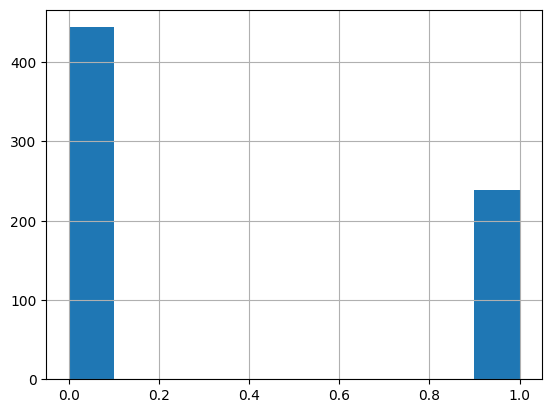

In [74]:
df_BC["Benign"].hist()

In [75]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

TARGET_COL = "Benign"
X = df_BC.drop(columns=[TARGET_COL])
y = df_BC[TARGET_COL]

print("Shape X:", X.shape, "| Shape y:", y.shape)
print("Répartition de la cible:n", y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

logreg = LogisticRegression(
    solver="liblinear",
    max_iter=500,
    class_weight="balanced",
    random_state=42
)
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)

print("nAccuracy (test):", round(accuracy_score(y_test, y_pred), 4))
print("nRapport de classification (test):")
print(classification_report(y_test, y_pred, digits=3))

coef = pd.Series(logreg.coef_[0], index=X.columns).sort_values(ascending=False)
print("nIntercept:", float(logreg.intercept_[0]))
print("nCoefficients (beta) :")
display(coef.to_frame(name="beta"))


Shape X: (683, 9) | Shape y: (683,)
Répartition de la cible:n Benign
0    444
1    239
Name: count, dtype: int64
nAccuracy (test): 0.9649
nRapport de classification (test):
              precision    recall  f1-score   support

           0      0.991     0.955     0.972       111
           1      0.922     0.983     0.952        60

    accuracy                          0.965       171
   macro avg      0.956     0.969     0.962       171
weighted avg      0.967     0.965     0.965       171

nIntercept: -5.769047483993969
nCoefficients (beta) :


,beta
BareNuclei,0.492783
UniformityOfCellShape,0.312884
UniformityOfCellSize,0.290715
ClumpThickness,0.231480
Mitoses,0.194093
NormalNucleoli,0.150516
MarginalAdhesion,0.140185
BlandChromatin,0.004105
SingleEpithelialCellSize,-0.009519


In [76]:
import numpy as np
from itertools import combinations
from gurobipy import GRB

# --- 1) w et courses depuis la logreg ---
courses = list(X.columns)
beta = dict(zip(courses, logreg.coef_[0]))
b0 = float(logreg.intercept_[0])

# score "risque cancer" = -(beta·x + b0)  => w = -beta pour que delta aille dans le bon sens
w = {k: -beta[k] for k in courses}

def cancer_risk_score(row_dict):
    return -(sum(beta[k] * row_dict[k] for k in courses) + b0)

# --- 2) échantillon de 10 lignes ---
S = df_BC.sample(n=20, random_state=50).reset_index(drop=True)
X10 = S[courses]

def row_to_dict(i):
    return X10.iloc[i].to_dict()

# --- 3) solveurs (tes 4 fonctions) ---
langs = {
    "1-1": lambda a, b: solve_11(a, b, w, courses, silent=True),
    "1-m": lambda a, b: solve_1m(a, b, w, courses, silent=True),
    "m-1": lambda a, b: solve_m1(a, b, w, courses, silent=True),
    "union": lambda a, b: solve_mixed(a, b, w, courses, silent=True),
}

# --- 4) comptage global ---
tot = 0
explained = {L: 0 for L in langs}

for i, j in combinations(range(20), 2):
    xi, xj = row_to_dict(i), row_to_dict(j)

    # orienter : a ≻ b = a plus à risque de cancer
    if cancer_risk_score(xi) >= cancer_risk_score(xj):
        a, b = xi, xj
    else:
        a, b = xj, xi

    tot += 1

    for L, solver in langs.items():
        status, _ = solver(a, b)
        if status == GRB.OPTIMAL:
            explained[L] += 1

# --- 5) taux global + ranking ---
rates = {L: explained[L] / tot for L in langs}
print(f"Total comparaisons = {tot}")
for L in ["1-1", "1-m", "m-1", "union"]:
    print(f"{L:>5} : {explained[L]}/{tot} = {rates[L]:.3f}")

ranking = sorted(rates.keys(), key=lambda L: rates[L], reverse=True)
print("nRanking (taux d'explication global) :", ranking)


ValueError: too many values to unpack (expected 2)

## Dataset RATP

In [ ]:
df_RATP=pd.read_csv("RATP_cleaned.csv")
df_RATP.head()

,Metro station,peak-entering-passengers/h,peak-passing-passengers/h,off-peak-entering-passengers/h,off-peak-passing-passengers/h,"strategic priority [0,10]","Station degradation level ([0,20] scale)","connectivity index [0,100]"
0,Odéon (Ligne 4),85000.0,8100.0,35500.0,3450.0,75.0,16.2,88.0
1,Place d'Italie (Lign 6),81000.0,8100.0,37500.0,3150.0,67.0,17.6,95.0
2,Jussieu (Ligne 7),74000.0,8900.0,37000.0,4050.0,68.0,16.8,79.0
3,Nation (Ligne 9),74000.0,7100.0,42000.0,4550.0,77.0,15.2,73.0
4,La Motte Picquet-Grenelle (Ligne 10),72000.0,7500.0,33000.0,4250.0,88.0,13.2,93.0


In [ ]:
poids= df_RATP[df_RATP["Metro station"] == "weights"]
df_RATP_clean = df_RATP[df_RATP["Metro station"] != "weights"].copy()


In [ ]:
poids

,Metro station,peak-entering-passengers/h,peak-passing-passengers/h,off-peak-entering-passengers/h,off-peak-passing-passengers/h,"strategic priority [0,10]","Station degradation level ([0,20] scale)","connectivity index [0,100]"
10,weights,0.021498,0.188111,0.037622,0.322477,16.123831,67.182629,16.123831


In [ ]:
import pandas as pd
from itertools import combinations
from gurobipy import Model, GRB, quicksum



def k_best_rankings_with_pool(df_RATP_clean, poids, TOPN=None, K=5, pool_solutions=50):
    # features + weights
    courses = [c for c in df_RATP_clean.columns if c != "Metro station"]
    w_row = poids.iloc[0]
    w = {k: float(w_row[k]) for k in courses}

    # scores dict
    scores = {
        row["Metro station"]: {k: float(row[k]) for k in courses}
        for _, row in df_RATP_clean.iterrows()
    }

    # score pondéré (sert à orienter les préférences + tie-break)
    def weighted_sum(x):
        return sum(w[k]  x[k] for k in courses)

    names_all = list(scores.keys())
    names_all.sort(key=lambda n: weighted_sum(scores[n]), reverse=True)
    if TOPN is None:
        names = names_all
    else:
        names = names_all[:min(TOPN, len(names_all))]

    
    solvers = [
        lambda a, b: solve_11(a, b, w, courses, silent=True),
        lambda a, b: solve_1m(a, b, w, courses, silent=True),
        lambda a, b: solve_m1(a, b, w, courses, silent=True),
        lambda a, b: solve_mixed(a, b, w, courses, silent=True),
    ]

    def explainable(a, b):
        for solve in solvers:
            status, _ = solve(a, b)
            if status == GRB.OPTIMAL:
                return True
        return False

    # préférences pref[i,j] ∈ {0,1}
    pref = {(i, j): 0 for i in names for j in names if i != j}

    for i, j in combinations(names, 2):
        xi, xj = scores[i], scores[j]
        si, sj = weighted_sum(xi), weighted_sum(xj)

        if si >= sj:
            better, worse = i, j
            a, b = xi, xj
        else:
            better, worse = j, i
            a, b = xj, xi

        if explainable(a, b):
            pref[(better, worse)] = 1

    # MILP de ranking : x[i,j]=1 si i est avant j
    m = Model("ranking_pool")
    m.params.OutputFlag = 0

    x = m.addVars(names, names, vtype=GRB.BINARY, name="x")

    for i in names:
        m.addConstr(x[i, i] == 0)

    for i, j in combinations(names, 2):
        m.addConstr(x[i, j] + x[j, i] == 1)

    # transitivité (pas de cycles de longueur 3)
    for i in names:
        for j in names:
            if j == i:
                continue
            for k in names:
                if k == i or k == j:
                    continue
                m.addConstr(x[i, j] + x[j, k] + x[k, i] <= 2)

    # objectif: max nb de préférences satisfaites
    m.setObjective(quicksum(pref[(i, j)]  x[i, j] for (i, j) in pref), GRB.MAXIMIZE)

    # 7) solution pool
    m.params.PoolSearchMode = 2
    m.params.PoolSolutions = pool_solutions
    m.params.PoolGap = 0
    m.optimize()

    if m.Status != GRB.OPTIMAL or m.SolCount == 0:
        return [], m

    # 8) extraction K classements depuis le même pool
    def extract_order_from_solution(sol_idx: int):
        m.params.SolutionNumber = sol_idx

        wins = {}
        for i in names:
            wins[i] = sum(1 for j in names if j != i and x[i, j].Xn > 0.5)

        # ordre déterministe : wins desc, puis score pondéré desc, puis nom
        order = sorted(
            names,
            key=lambda n: (wins[n], weighted_sum(scores[n]), n),
            reverse=True
        )
        return order

    sol_to_read = min(K, m.SolCount)
    rankings = [extract_order_from_solution(s) for s in range(sol_to_read)]
    return rankings, m



rankings, model = k_best_rankings_with_pool(df_RATP_clean, poids, TOPN=None, K=5, pool_solutions=50)

rank3 = rankings[:3]
rank5 = rankings[:5]

print("Top 3 classements :")
for idx, r in enumerate(rank3, 1):
    print(f"#{idx} :", r)

print("nTop 5 classements :")
for idx, r in enumerate(rank5, 1):
    print(f"#{idx} :", r)


Top 3 classements :
#1 : ['Odéon (Ligne 4)', "Place d'Italie (Lign 6)", 'La Motte Picquet-Grenelle (Ligne 10)', 'Jussieu (Ligne 7)', 'Nation (Ligne 9)', "Porte d'Orléans (Ligne 4)", 'Oberkampf (Ligne 9)', 'Reuilly-Diderot (Ligne 1)', 'Daumenil (Ligne 6)', 'Vaugirard (Ligne 12)']
#2 : ['Jussieu (Ligne 7)', 'Odéon (Ligne 4)', "Place d'Italie (Lign 6)", 'La Motte Picquet-Grenelle (Ligne 10)', 'Nation (Ligne 9)', "Porte d'Orléans (Ligne 4)", 'Oberkampf (Ligne 9)', 'Reuilly-Diderot (Ligne 1)', 'Daumenil (Ligne 6)', 'Vaugirard (Ligne 12)']
#3 : ['Odéon (Ligne 4)', 'Jussieu (Ligne 7)', "Place d'Italie (Lign 6)", 'La Motte Picquet-Grenelle (Ligne 10)', 'Nation (Ligne 9)', "Porte d'Orléans (Ligne 4)", 'Oberkampf (Ligne 9)', 'Reuilly-Diderot (Ligne 1)', 'Daumenil (Ligne 6)', 'Vaugirard (Ligne 12)']

Top 5 classements :
#1 : ['Odéon (Ligne 4)', "Place d'Italie (Lign 6)", 'La Motte Picquet-Grenelle (Ligne 10)', 'Jussieu (Ligne 7)', 'Nation (Ligne 9)', "Porte d'Orléans (Ligne 4)", 'Oberkampf (Ligne

Graph

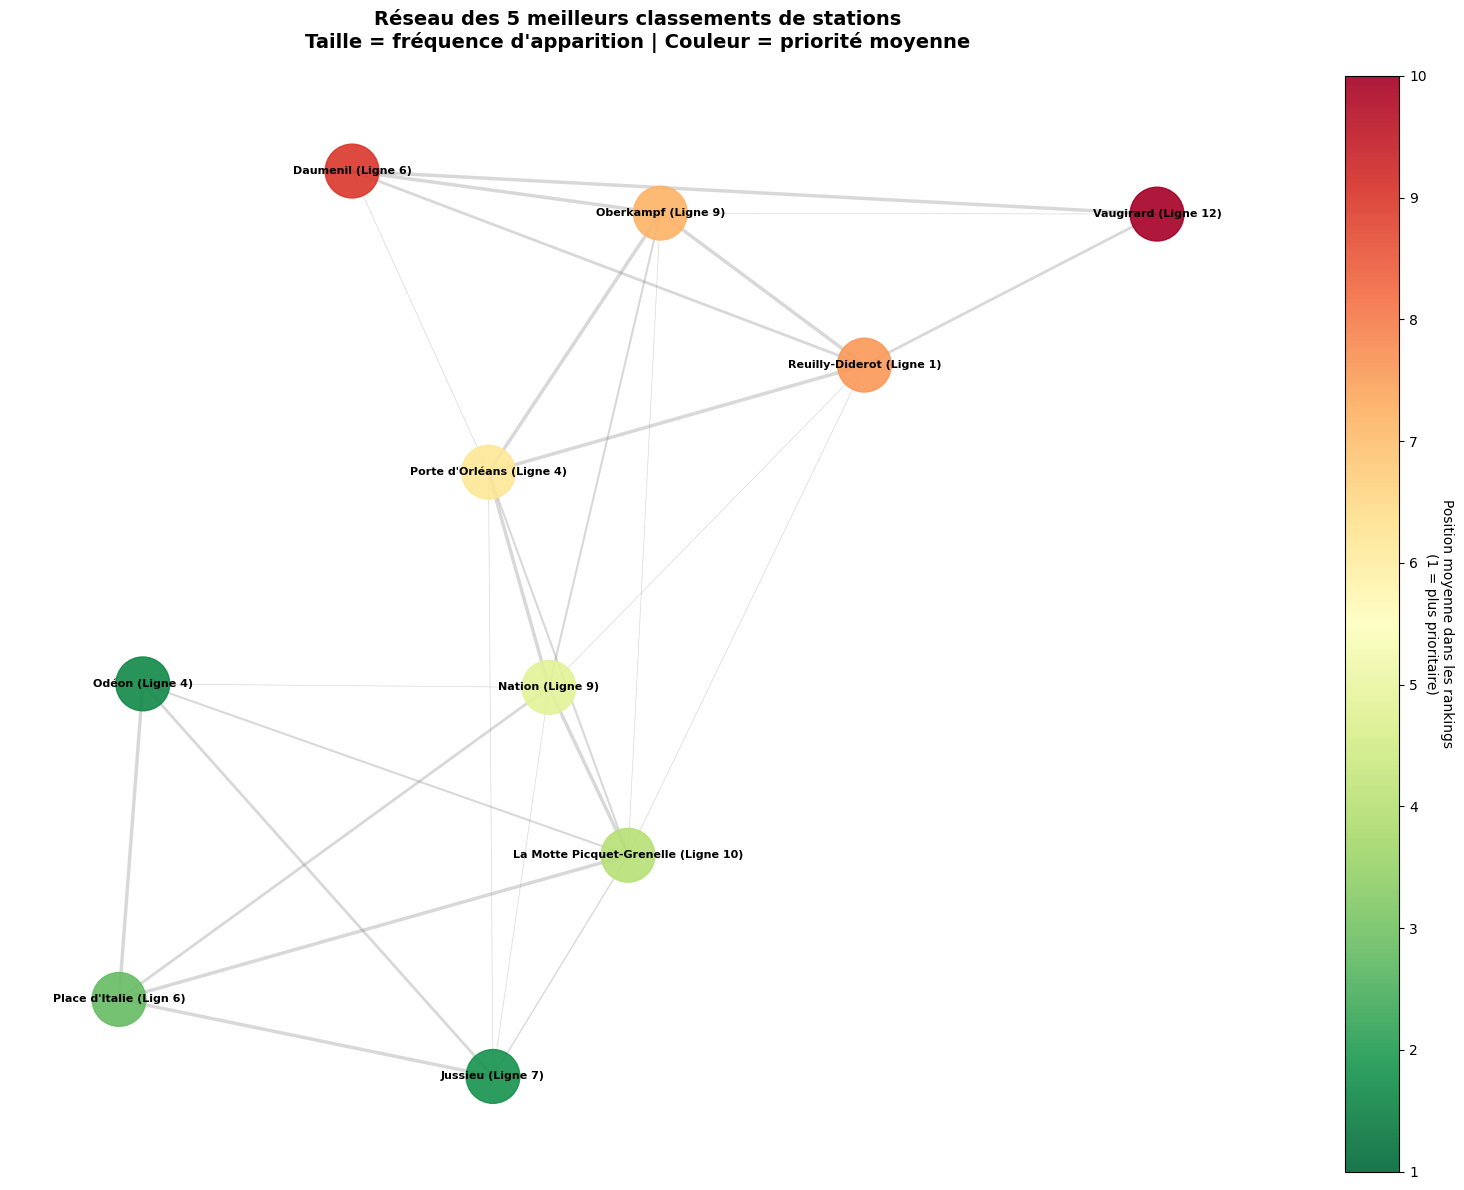

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

def visualize_kbest_network(rankings, df_clean, top_k=5):
    """
    Visualise les k-best rankings sous forme de graphe.
    - Nœuds = stations de métro
    - Taille des nœuds = fréquence d'apparition dans le top 5
    - Couleur = position moyenne dans les rankings
    """
    
    # 1) Créer le graphe
    G = nx.Graph()
    
    # 2) Analyser les rankings
    all_stations = set()
    station_positions = {}  # station -> liste des positions
    
    for ranking in rankings[:top_k]:
        for pos, station in enumerate(ranking[:10], 1):  # Top 10 de chaque ranking
            all_stations.add(station)
            if station not in station_positions:
                station_positions[station] = []
            station_positions[station].append(pos)
    
    # 3) Calculer les métriques pour chaque station
    station_metrics = {}
    for station in all_stations:
        positions = station_positions.get(station, [])
        station_metrics[station] = {
            'avg_position': np.mean(positions) if positions else 999,
            'frequency': len(positions),
            'best_position': min(positions) if positions else 999
        }
    
    # 4) Ajouter les nœuds
    G.add_nodes_from(all_stations)
    
    # 5) Ajouter des arêtes entre stations qui apparaissent souvent ensemble
    # (stations proches dans les rankings)
    for ranking in rankings[:top_k]:
        top10 = ranking[:10]
        for i in range(len(top10)-1):
            for j in range(i+1, min(i+3, len(top10))):  # Connecter aux 2 suivantes
                if G.has_edge(top10[i], top10[j]):
                    G[top10[i]][top10[j]]['weight'] += 1
                else:
                    G.add_edge(top10[i], top10[j], weight=1)
    
    # 6) Préparer la visualisation
    fig, ax = plt.subplots(figsize=(16, 12))
    
    # Position des nœuds
    pos = nx.spring_layout(G, k=2, iterations=50, seed=42)
    
    # Taille des nœuds (basée sur la fréquence)
    node_sizes = [station_metrics[node]['frequency']  300 for node in G.nodes()]
    
    # Couleur des nœuds (basée sur la position moyenne)
    node_colors = [station_metrics[node]['avg_position'] for node in G.nodes()]
    
    # Largeur des arêtes
    edge_widths = [G[u][v]['weight']  0.5 for u, v in G.edges()]
    
    # Dessiner le graphe
    nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.3, edge_color='gray', ax=ax)
    
    nodes = nx.draw_networkx_nodes(
        G, pos,
        node_size=node_sizes,
        node_color=node_colors,
        cmap=plt.cm.RdYlGn_r,  # Rouge = haute priorité, Vert = basse priorité
        alpha=0.9,
        ax=ax,
        vmin=1,
        vmax=10
    )
    
    # Labels
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', ax=ax)
    
    # Colorbar
    cbar = plt.colorbar(nodes, ax=ax)
    cbar.set_label('Position moyenne dans les rankingsn(1 = plus prioritaire)', 
                   rotation=270, labelpad=20, fontsize=10)
    
    # Titre et légendes
    ax.set_title(f'Réseau des {top_k} meilleurs classements de stationsn' + 
                 'Taille = fréquence d'apparition | Couleur = priorité moyenne',
                 fontsize=14, fontweight='bold', pad=20)
    ax.axis('off')
    
    plt.tight_layout()
    return fig, station_metrics



# UTILISATION après votre code existant :
rankings, model = k_best_rankings_with_pool(df_RATP_clean, poids, TOPN=None, K=5, pool_solutions=50)

# Graphique 1 : Réseau
fig1, metrics = visualize_kbest_network(rankings, df_RATP_clean, top_k=5)
plt.savefig('network_kbest.png', dpi=300, bbox_inches='tight')
plt.show()


## Dataset 27crit

In [ ]:
crit=pd.read_csv("data27crit.csv", sep=";")
crit.head()

poids= crit[crit["sol"] == "weights"]
crit_clean = crit[crit["sol"] != "weights"].copy()


In [ ]:
crit_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4 entries, 0 to 3
Data columns (total 28 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   sol     4 non-null      object
 1   a       4 non-null      int64 
 2   b       4 non-null      int64 
 3   c       4 non-null      object
 4   d       4 non-null      object
 5   e       4 non-null      object
 6   f       4 non-null      object
 7   g       4 non-null      int64 
 8   h       4 non-null      object
 9   i       4 non-null      object
 10  j       4 non-null      object
 11  k       4 non-null      int64 
 12  l       4 non-null      object
 13  m       4 non-null      int64 
 14  n       4 non-null      int64 
 15  o       4 non-null      int64 
 16  p       4 non-null      int64 
 17  q       4 non-null      object
 18  r       4 non-null      object
 19  s       4 non-null      int64 
 20  t       4 non-null      int64 
 21  u       4 non-null      int64 
 22  v       4 non-null      int64 
 23 

In [ ]:
import pandas as pd

crit = pd.read_csv("data27crit.csv", sep=";", decimal=",")  # decimal="," au cas où
mask_w = crit["sol"].astype(str).str.strip().eq("weights")

poids = crit.loc[mask_w].copy()
crit_clean = crit.loc[~mask_w].copy()

assert len(poids) == 1, f"Je trouve {len(poids)} ligne(s) 'weights' (attendu 1)."


In [ ]:
from itertools import combinations
from gurobipy import Model, GRB, quicksum

def k_best_rankings_with_pool(df_clean, poids, TOPN=None, K=5, pool_solutions=50, id_col="sol"):
    # colonnes critères = toutes sauf id_col
    courses = [c for c in df_clean.columns if c != id_col]

    # weights dict
    w_row = poids.iloc[0]
    w = {k: float(w_row[k]) for k in courses}  # <-- plus d'erreur "weights"

    # scores dict : name -> features
    scores = {
        row[id_col]: {k: float(row[k]) for k in courses}
        for _, row in df_clean.iterrows()
    }

    def weighted_sum(x):
        return sum(w[k]  x[k] for k in courses)

    names_all = list(scores.keys())
    names_all.sort(key=lambda n: weighted_sum(scores[n]), reverse=True)
    names = names_all if TOPN is None else names_all[:min(TOPN, len(names_all))]

    # --- préférence: ici je reste "simple" => i avant j si score(i) >= score(j)
    # (si tu veux remettre "expliquable par langages", tu le ré-branches après)
    pref = {(i, j): 0 for i in names for j in names if i != j}
    for i, j in combinations(names, 2):
        if weighted_sum(scores[i]) >= weighted_sum(scores[j]):
            pref[(i, j)] = 1
        else:
            pref[(j, i)] = 1

    # --- MILP ranking + pool ---
    m = Model("ranking_pool")
    m.Params.OutputFlag = 0

    x = m.addVars(names, names, vtype=GRB.BINARY, name="x")
    for i in names:
        m.addConstr(x[i, i] == 0)
    for i, j in combinations(names, 2):
        m.addConstr(x[i, j] + x[j, i] == 1)

    for i in names:
        for j in names:
            if j == i: 
                continue
            for k in names:
                if k == i or k == j:
                    continue
                m.addConstr(x[i, j] + x[j, k] + x[k, i] <= 2)

    m.setObjective(quicksum(pref[(i, j)]  x[i, j] for (i, j) in pref), GRB.MAXIMIZE)

    m.Params.PoolSearchMode = 2
    m.Params.PoolSolutions = pool_solutions
    m.Params.PoolGap = 0
    m.optimize()

    if m.Status != GRB.OPTIMAL or m.SolCount == 0:
        return [], m

    def extract_order(sol_idx):
        m.Params.SolutionNumber = sol_idx
        wins = {i: sum(1 for j in names if j != i and x[i, j].Xn > 0.5) for i in names}
        return sorted(names, key=lambda n: (wins[n], weighted_sum(scores[n]), n), reverse=True)

    rankings = [extract_order(s) for s in range(min(K, m.SolCount))]
    return rankings, m


In [ ]:
rankings, model = k_best_rankings_with_pool(crit_clean, poids, TOPN=None, K=5, pool_solutions=50, id_col="sol")

rank3 = rankings[:3]
rank5 = rankings[:5]

print("Top 3 classements :")
for idx, r in enumerate(rank3, 1):
    print(f"#{idx} :", r)

print("nTop 5 classements :")
for idx, r in enumerate(rank5, 1):
    print(f"#{idx} :", r)


Top 3 classements :
#1 : ['solution 1', 'solution 2', 'solution 4', 'solution 3']

Top 5 classements :
#1 : ['solution 1', 'solution 2', 'solution 4', 'solution 3']
